In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import scipy

In [142]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [2]:
basal_order = ['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2']

In [3]:
def find_section_number(path):
    # section number will always be somewhere in string as U followed by digits, e.g. U1, U2, U3, etc.
    match = re.search(r'U\d+', path.stem)
    if match:
        return match.group(0)
    else:
        raise ValueError(f"No section number found in path: {path}")

In [49]:
directory = Path('~/Downloads/HT704B1_regions').expanduser()

section_to_cell_path = {
    find_section_number(p): p for p in directory.rglob('*U[0-9]*.h5ad')
}

section_to_boundary_counts_path = {
    find_section_number(p): p for p in directory.rglob('*U[0-9]*_boundary_counts.txt')
}

section_to_ring_labeled_path = {
    find_section_number(p): p for p in directory.rglob('*U[0-9]*_ring_labeled.npy')
}

section_to_region_labeled_path = {
    find_section_number(p): p for p in directory.rglob('*U[0-9]*_region_labeled.npy')
}

len(section_to_cell_path), len(section_to_boundary_counts_path), len(section_to_region_labeled_path)

(12, 12, 12)

In [50]:
section_to_z = {
    'U1': 0,
    'U2': 5,
    'U14': 65,
    'U17': 80,
    'U22': 105,
    'U26': 125,
    'U33': 160,
    'U41': 200,
    'U47': 230,
    'U50': 245,
    'U51': 250,
    'U56': 275,
}

In [ ]:
exclude_keys = [
    # 'U2',
    # 'U51',
    # 'U14',
    # 'U47',
    # 'U22',
    # 'U56',
]

keys = sorted(set(section_to_cell_path.keys()))
keys = [k for k in keys if k not in exclude_keys]
keys

['U1', 'U17', 'U26', 'U33', 'U41', 'U50']

In [53]:
section_to_cell_path = {k: v for k, v in section_to_cell_path.items() if k in keys}
section_to_boundary_counts_path = {k: v for k, v in section_to_boundary_counts_path.items() if k in keys}
section_to_region_labeled_path = {k: v for k, v in section_to_region_labeled_path.items() if k in keys}
section_to_ring_labeled_path = {k: v for k, v in section_to_ring_labeled_path.items() if k in keys}

In [131]:
def extract_tam_coordinates(adata):
    # annotate cells with at least 1 count of CD68 and Spp1 as SPP1+ TAMs

    # need to convert X from sparse matrix to dense array and flatten to 1D
    epcam_counts = adata[:, 'EPCAM'].X.toarray().flatten()
    mono_counts = adata[:, 'CD68'].X.toarray().flatten() + adata[:, 'CD163'].X.toarray().flatten() + adata[:, 'CSF1R'].X.toarray().flatten() + adata[:, 'CD14'].X.toarray().flatten()

    spp1_counts = adata[:, 'SPP1'].X.toarray().flatten()
    ms4a6a_counts = adata[:, 'MS4A6A'].X.toarray().flatten()

    adata.obs['SPP1_TAMs'] = (mono_counts > 0) & (spp1_counts > 0) & (ms4a6a_counts == 0) & (epcam_counts == 0)

    adata.obs['MS4A6A_TAMs'] = (mono_counts > 0) & (spp1_counts == 0) & (ms4a6a_counts > 0) & (epcam_counts == 0)

    adata.obs['label'] = 'other'
    adata.obs.loc[adata.obs['SPP1_TAMs'], 'label'] = 'SPP1+ TAM'
    adata.obs.loc[adata.obs['MS4A6A_TAMs'], 'label'] = 'MS4A6A+ TAM'

    # extract spatial coordinates of each tam subtype
    coords = adata.obsm['spatial']
    if isinstance(coords, pd.DataFrame):
        coords = coords.to_numpy()
    else:
        coords = np.asarray(coords)

    spp1_mask = adata.obs['SPP1_TAMs'].to_numpy()
    ms4a6a_mask = adata.obs['MS4A6A_TAMs'].to_numpy()
    spp1_coords = coords[spp1_mask]
    ms4a6a_coords = coords[ms4a6a_mask]

    return spp1_coords, ms4a6a_coords

def generate_basal_count_img(region_labeled, ring_labeled, boundary_df, basal_order):
    basal_counts = boundary_df[[c for c in basal_order if c in boundary_df.columns]].iloc[:, 0].values
    region_to_basal_count = dict(zip(boundary_df.iloc[:, 0], basal_counts))
    basal_count_img = np.zeros(region_labeled.shape)
    for region_id, basal_count in region_to_basal_count.items():
        # value needs to be normalized by region size
        value = basal_count / np.sum(ring_labeled == region_id)
        basal_count_img[region_labeled == region_id] = value
    
    # normalize basal count image to [0, 1]
    basal_count_img = basal_count_img / np.max(basal_count_img)

    # set zero to nan
    basal_count_img[basal_count_img == 0] = np.nan

    return basal_count_img

def generate_distribution_table(spp1_coords, ms4a6a_coords, img, scaler=0.1):
    # downsample coordinates to match image resolution
    spp1_coords_down = spp1_coords * scaler
    ms4a6a_coords_down = ms4a6a_coords * scaler

    # coords are x, y but image is indexed as row (y), column (x), so need to swap coordinates
    spp1_coords_down = spp1_coords_down[:, ::-1]
    ms4a6a_coords_down = ms4a6a_coords_down[:, ::-1]

    # for every cell in spp1 and ms4a6a, get the nearest non-null pixel value in the basal count image
    from scipy.spatial import cKDTree
    # get coordinates of non-null pixels in basal count image
    non_null_coords = np.argwhere(~np.isnan(img))
    tree = cKDTree(non_null_coords)
    
    # query nearest non-null pixel for each cell coordinate
    spp1_distances, spp1_indices = tree.query(spp1_coords_down)
    ms4a6a_distances, ms4a6a_indices = tree.query(ms4a6a_coords_down)

    # get basal count values for nearest pixels
    spp1_basal_counts = img[non_null_coords[spp1_indices][:, 0], non_null_coords[spp1_indices][:, 1]]
    ms4a6a_basal_counts = img[non_null_coords[ms4a6a_indices][:, 0], non_null_coords[ms4a6a_indices][:, 1]]

    # make a dataframe with columns: 'x', 'y', 'TAM subtype', 'Region Basal Cell Count', 'Distance to Nearest Region with Basal Cells'
    spp1_df = pd.DataFrame({
        'x': spp1_coords[:, 0],
        'y': spp1_coords[:, 1],
        'TAM subtype': 'SPP1+ TAM',
        'Region Basal Score': spp1_basal_counts,
        'Distance to Nearest Region': spp1_distances
    })

    ms4a6a_df = pd.DataFrame({
        'x': ms4a6a_coords[:, 0],
        'y': ms4a6a_coords[:, 1],
        'TAM subtype': 'MS4A6A+ TAM',
        'Region Basal Score': ms4a6a_basal_counts,
        'Distance to Nearest Region': ms4a6a_distances
    })

    distribution_df = pd.concat([spp1_df, ms4a6a_df], ignore_index=True)

    return distribution_df

def generate_img_volume(section_to_img, section_to_z, z_scaler=0.1):
    # get sorted sections by z value
    sections = sorted(section_to_img.keys(), key=lambda s: section_to_z[s])
    z_values = [section_to_z[s] for s in sections]
    imgs = [section_to_img[s] for s in sections]
    z_max = max(z_values)

    # get shape of images
    img_shape = imgs[0].shape
    
    # create empty volume with shape (z, y, x) where z is determined by max z value and z_scaler, and y and x are determined by image shape
    z_dim = int(z_max * z_scaler) + 1
    img_volume = np.zeros((z_dim, img_shape[0], img_shape[1]))

    # fill volume with images at corresponding z indices determined by section_to_z and z_scaler
    for section, img in section_to_img.items():
        # get resized img if it doesnt match the shape of the first image, which determines the shape of the volume
        # using nearest neighbor interpolation for resizing to preserve 
        if img.shape != img_shape:
            img = scipy.ndimage.zoom(img, (img_shape[0] / img.shape[0], img_shape[1] / img.shape[1]), order=0)

        z_index = int(section_to_z[section] * z_scaler)
        img_volume[z_index, :, :] = img
    
    # set zero to nan
    img_volume[img_volume == 0] = np.nan

    return img_volume

def generate_distribution_table_3d(spp1_coords, ms4a6a_coords, volume, scaler=0.1):
    # downsample coordinates to match image resolution
    spp1_coords_down = spp1_coords * scaler
    ms4a6a_coords_down = ms4a6a_coords * scaler

    # coords are x, y but volume is indexed as z, row (y), column (x), so need to swap coordinates
    spp1_coords_down = spp1_coords_down[:, ::-1]
    ms4a6a_coords_down = ms4a6a_coords_down[:, ::-1]

    # for every cell in spp1 and ms4a6a, get the nearest non-null voxel value in the basal count volume
    from scipy.spatial import cKDTree
    # get coordinates of non-null voxels in basal count volume
    non_null_coords = np.argwhere(~np.isnan(volume))
    tree = cKDTree(non_null_coords)
    
    # # query nearest non-null voxel for each cell coordinate, need to add z coordinate to cell coordinates for querying
    # spp1_coords_3d = np.hstack([spp1_coords_down, np.zeros((spp1_coords_down.shape[0], 1))])
    # ms4a6a_coords_3d = np.hstack([ms4a6a_coords_down, np.zeros((ms4a6a_coords_down.shape[0], 1))])
    
    spp1_distances, spp1_indices = tree.query(spp1_coords_down)
    ms4a6a_distances, ms4a6a_indices = tree.query(ms4a6a_coords_down)
   
    print(f"Average distance to nearest region for SPP1+ TAMs: {np.mean(spp1_distances)}")
    print(f"Average distance to nearest region for MS4A6A+ TAMs: {np.mean(ms4a6a_distances)}")
    print(f'Average z index: {np.mean(non_null_coords[spp1_indices][:, 0])}', )

    # get basal count values for nearest voxels
    spp1_basal_counts = volume[non_null_coords[spp1_indices][:, 0], non_null_coords[spp1_indices][:, 1], non_null_coords[spp1_indices][:, 2]]
    ms4a6a_basal_counts = volume[non_null_coords[ms4a6a_indices][:, 0], non_null_coords[ms4a6a_indices][:, 1], non_null_coords[ms4a6a_indices][:, 2]]

    # # divide by distance to region
    # spp1_basal_counts /= spp1_distances + 1
    # ms4a6a_basal_counts /= ms4a6a_distances + 1

    # z score 
    mean = np.nanmean(np.concat((spp1_basal_counts, ms4a6a_basal_counts)))
    std = np.nanstd(np.concat((spp1_basal_counts, ms4a6a_basal_counts)))
    spp1_basal_counts = (spp1_basal_counts - mean) / std
    ms4a6a_basal_counts = (ms4a6a_basal_counts - mean) / std

    # make a dataframe with columns: 'x', 'y', 'TAM subtype', 'Region Basal Cell Count', 'Distance to Nearest Region with Basal Cells'
    spp1_df = pd.DataFrame({
        'x': spp1_coords[:, 0],
        'y': spp1_coords[:, 1],
        'TAM subtype': 'SPP1+ TAM',
        'Region Basal Score': spp1_basal_counts,
        'Distance to Nearest Region': spp1_distances
    })

    ms4a6a_df = pd.DataFrame({
        'x': ms4a6a_coords[:, 0],
        'y': ms4a6a_coords[:, 1],
        'TAM subtype': 'MS4A6A+ TAM',
        'Region Basal Score': ms4a6a_basal_counts,
        'Distance to Nearest Region': ms4a6a_distances
    })

    distribution_df = pd.concat([spp1_df, ms4a6a_df], ignore_index=True)

    return distribution_df
    


In [82]:
section_to_img = {}
for section in section_to_region_labeled_path.keys():
    print(section)
    region_labeled = np.load(section_to_region_labeled_path[section])
    ring_labeled = np.load(section_to_ring_labeled_path[section])
    boundary_df = pd.read_csv(section_to_boundary_counts_path[section], sep='\t')
    img = generate_basal_count_img(region_labeled, ring_labeled, boundary_df, basal_order)
    section_to_img[section] = img

U41
U33
U17
U1
U26
U50


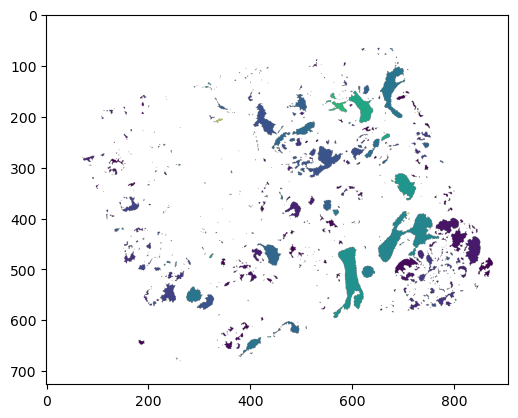

In [83]:
img = section_to_img['U1']
plt.imshow(img, vmax=1)

In [84]:
all_distribution_tables = []
for section, adata in section_to_cell_path.items():
    print(section)
    adata = sc.read_h5ad(adata)
    spp1_coords, ms4a6a_coords = extract_tam_coordinates(adata)
    distribution_table = generate_distribution_table(spp1_coords, ms4a6a_coords, section_to_img[section], scaler=0.1)
    distribution_table['Section'] = section
    distribution_table['Z'] = section_to_z[section]
    all_distribution_tables.append(distribution_table)
overall_table = pd.concat(all_distribution_tables, ignore_index=True)

U41
U17
U26
U50
U33
U1


In [60]:
for section, img in section_to_img.items():
    print(section, img.shape)

U41 (581, 847)
U33 (581, 847)
U17 (725, 846)
U1 (726, 907)
U26 (582, 846)
U50 (653, 787)


In [61]:
volume = generate_img_volume(section_to_img, section_to_z)
volume.shape

(25, 726, 907)

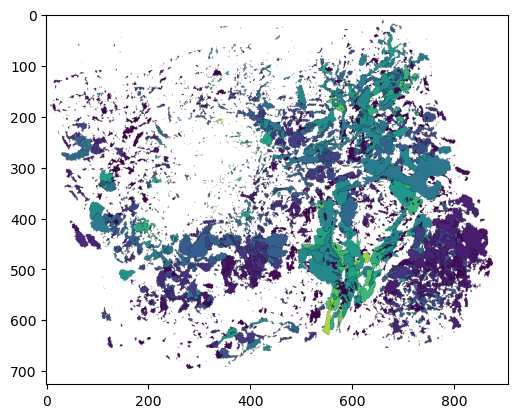

In [101]:
for x in volume:
    plt.imshow(x)
    # plt.show()

In [132]:
all_distribution_tables = []
for section, adata in section_to_cell_path.items():
    adata = sc.read_h5ad(adata)
    spp1_coords, ms4a6a_coords = extract_tam_coordinates(adata)
    z = section_to_z[section]

    # add z coordinate to spp1 and ms4a6a coordinates for potential 3d analysis later
    spp1_coords = np.hstack([spp1_coords, np.full((spp1_coords.shape[0], 1), z)])
    ms4a6a_coords = np.hstack([ms4a6a_coords, np.full((ms4a6a_coords.shape[0], 1), z)])
    distribution_table = generate_distribution_table_3d(spp1_coords, ms4a6a_coords, volume)
    distribution_table['Section'] = section
    distribution_table['Z'] = section_to_z[section]
    all_distribution_tables.append(distribution_table)
overall_table = pd.concat(all_distribution_tables, ignore_index=True)

Average distance to nearest region for SPP1+ TAMs: 6.5448171400165105
Average distance to nearest region for MS4A6A+ TAMs: 5.162826043989213
Average z index: 18.677717810331533
Average distance to nearest region for SPP1+ TAMs: 5.321169790294746
Average distance to nearest region for MS4A6A+ TAMs: 6.546843659648548
Average z index: 9.130801687763713
Average distance to nearest region for SPP1+ TAMs: 6.6028714546235205
Average distance to nearest region for MS4A6A+ TAMs: 5.280851004763603
Average z index: 13.216077170418007
Average distance to nearest region for SPP1+ TAMs: 6.700399620984094
Average distance to nearest region for MS4A6A+ TAMs: 6.917842606355692
Average z index: 20.910112359550563
Average distance to nearest region for SPP1+ TAMs: 5.99879747128318
Average distance to nearest region for MS4A6A+ TAMs: 4.900801460067777
Average z index: 16.277448588358315
Average distance to nearest region for SPP1+ TAMs: 7.752891580792347
Average distance to nearest region for MS4A6A+ TAMs

In [133]:
overall_table

,x,y,TAM subtype,Region Basal Score,Distance to Nearest Region,Section,Z
0,238,1516,SPP1+ TAM,-1.183117,9.654015,U41,200
1,152,1327,SPP1+ TAM,-0.941260,4.016217,U41,200
2,219,1291,SPP1+ TAM,-0.941260,4.101219,U41,200
3,228,1285,SPP1+ TAM,-0.941260,4.276681,U41,200
4,239,1287,SPP1+ TAM,-0.941260,4.207137,U41,200
...,...,...,...,...,...,...,...
162366,7144,1609,MS4A6A+ TAM,-0.928260,6.063827,U1,0
162367,7149,1681,MS4A6A+ TAM,-0.923444,4.244997,U1,0
162368,6869,1791,MS4A6A+ TAM,0.931767,7.669420,U1,0
162369,6955,1466,MS4A6A+ TAM,2.094899,8.025584,U1,0


<Axes: >

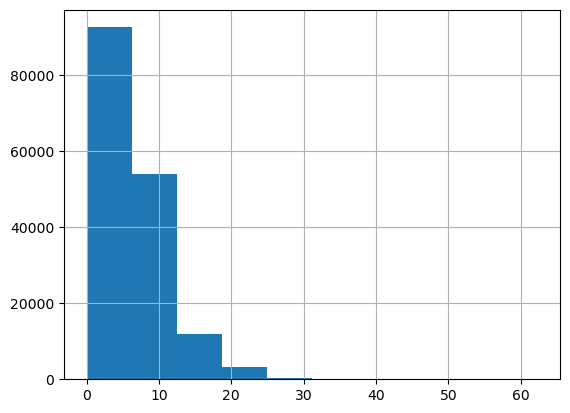

In [134]:
overall_table['Distance to Nearest Region'].hist()

In [ ]:
sns.boxplot(x='Z', y='Region Basal Score', data=overall_table, hue='TAM subtype', showfliers=False, whis=1., orient='v')
# sns.violinplot(x='Z', y='Region Basal Score', data=overall_table, hue='TAM subtype')

# log scale yaxis
# plt.yscale('log')

plt.savefig('/Users/erikstorrs/Downloads/tam_subtype_plot.svg')

KeyboardInterrupt: 

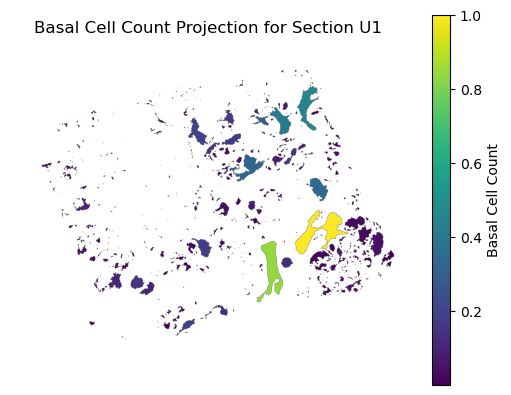

In [79]:

plt.imshow(img, cmap='viridis')
plt.colorbar(label='Basal Cell Count')
plt.title(f'Basal Cell Count Projection for Section {section}')
plt.axis('off')
plt.show()

In [153]:
adata = sc.read_h5ad(section_to_cell_path['U14'])
adata

AnnData object with n_obs × n_vars = 127844 × 1000
    obs: 'cell_ID', 'Area', 'fov', 'CenterX_global_px', 'CenterY_global_px', 'n_counts'
    var: 'n_cells'
    uns: 'log1p', 'ome'
    obsm: 'spatial'
    layers: 'counts'

In [155]:
adata.obsm['spatial']

,CenterX_global_px,CenterY_global_px
cell_id,,
c_1_1_1,10249.999885,38692.686794
c_1_1_2,10588.686017,38022.978765
c_1_1_3,10735.766309,38006.190443
c_1_1_5,10706.569228,37925.168546
c_1_1_12,10606.204265,37964.219640
...,...,...
c_1_171_134,23560.948618,20039.402352
c_1_171_135,23716.058107,20021.154176
c_1_171_136,24020.802633,20009.110381


In [58]:
spp1_coords, ms4a6a_coords = extract_tam_coordinates(adata)

(np.float64(106.5),
 np.float64(9093.5),
 np.float64(7318.75),
 np.float64(372.25))

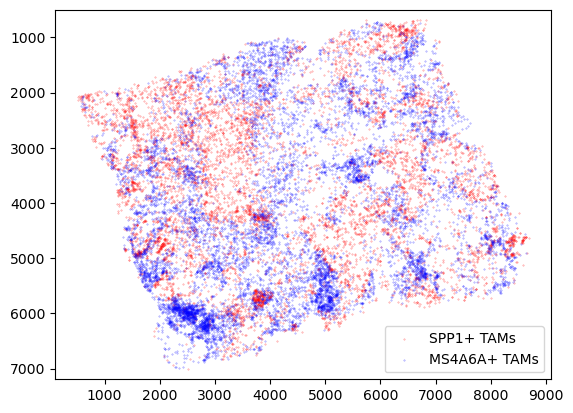

In [61]:
plt.scatter(spp1_coords[:, 0], spp1_coords[:, 1], color='red', label='SPP1+ TAMs', alpha=0.5, s=.1)
plt.scatter(ms4a6a_coords[:, 0], ms4a6a_coords[:, 1], color='blue', label='MS4A6A+ TAMs', alpha=0.5, s=.1)
plt.legend()

# invert y-axis to match spatial image orientation
plt.gca().invert_yaxis()
plt.axis('equal')


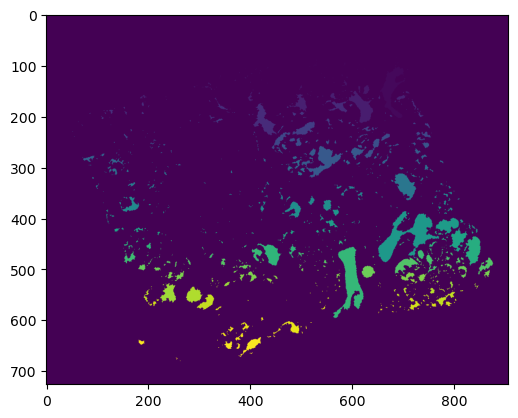

In [8]:
plt.imshow(d)

In [11]:
df = pd.read_csv('/Users/erikstorrs/Downloads/HT704B1_regions/HT704B1-S1H3Fp1U1_boundary_counts.txt', sep='\t')
df.head()

,region_id,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAM8,ADAMTS1,ADGRE1,...,UPK3B,UnassignedCodeword_0006,UnassignedCodeword_0037,UnassignedCodeword_0069,UnassignedCodeword_0412,VCAN,VEGFA,VSIG4,VWA5A,VWF
0,1,9,0,0,94,251,3,3,10,0,...,0,0,0,0,0,39,134,5,20,1
1,2,12,1,0,44,199,5,2,1,0,...,0,0,0,0,0,30,128,2,25,0
2,3,4,0,0,207,154,4,7,26,0,...,0,0,0,0,0,66,67,2,44,0
3,4,7,1,0,8,53,1,1,0,0,...,0,0,0,0,0,8,33,0,6,0
4,5,4,1,1,30,128,2,1,1,0,...,1,0,0,0,0,56,63,2,14,3


In [ ]:
basal_order = ['KRT5', 'KRT14', 'KRT15', 'LAMB3', 'ACTA2']


